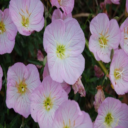

In [24]:
import torchvision
import torch
from PIL import Image

size = (128,128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = list(torchvision.datasets.Flowers102("./flowers", 'train', transform=transform, download = True))
test_dataset = list(torchvision.datasets.Flowers102("./flowers", 'test', transform=transform, download = True))


def visualize_image(img: torch.Tensor) ->Image.Image:
    return Image.fromarray((img.permute(1,2,0) * 255).to(torch.uint8).numpy())

visualize_image(train_dataset[0][0])


In [25]:
train_dataset[0][1] #[0] has image data, [1] has label

0

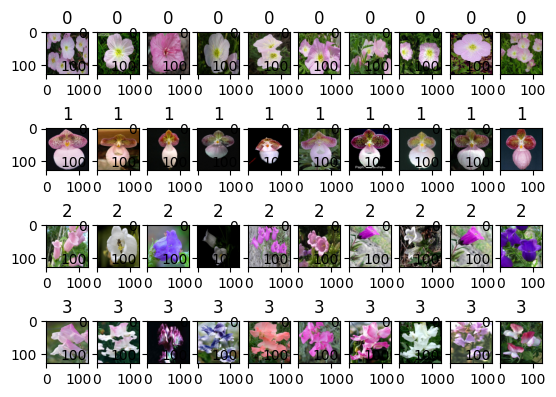

In [26]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(4,10)

for i, (im, l) in enumerate(train_dataset[:40]):
    ax[i//10,i%10].imshow(visualize_image(im))
    ax[i//10,i%10].set_title(l)


class_01 = train_dataset[0:20]


# Nearest neighbor

f: R -> {0,1}

* Input x
* Find closest data point (mean(x), l) element D in dataset D
* Return its label l

In [28]:
def nn_classifier(x):
    #comput distance between input x and each image
    dist = [((x - im).pow(2).sum(),l) for im, l in class_01]
    #could get argmin and then use that arg to get label, but easier to just make a tuple and get min tuple
    return min(dist)[1]



nn_classifier(test_dataset[0][0])

accuracy = sum(nn_classifier(x) == l for x, l in test_dataset[0:20]) / 20

In [29]:
print(accuracy)

0.4


In [31]:
[l for _,l in test_dataset[:20]]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# K nearest neighbor

f: R->R

* Input x
* Find k closest datapoints in dataset D
* Return most common label

In [41]:
def knn_classifier(x, k = 3):
    #comput distance between input x and each image
    dist = [((x - im).pow(2).sum(),l) for im, l in class_01]

    #sort distances and take k closest. Then get label

    #with only 2 classes, the most frequent is just the median
    k_closest = [l for _, l in sorted(dist)[:k]]
    return sorted(k_closest)[k//2]




knn_classifier(test_dataset[2][0])

accuracy = sum(knn_classifier(x) == l for x, l in test_dataset[0:20]) / 20

In [42]:
accuracy

0.5

# Knn regression

f: R-> R

* Input x
* Find k closest datapoints in dataset D
* Return avg value

In [52]:
def knn_regressor(x, k = 3):
    #comput distance between input x and each image
    dist = [((x - im).pow(2).sum(),l) for im, l in class_01]

    #sort distances and take k closest. Then get label

    #with only 2 classes, the most frequent is just the median
    k_closest = [l for _, l in sorted(dist)[:k]]

    #mean of the labels. Covert to float to avoid error
    return torch.mean(torch.tensor(k_closest).float())




knn_regressor(test_dataset[2][0])

#accuracy = sum(knn_regressor(x) == l for x, l in test_dataset[0:20]) / 20

tensor(0.3333)